# 12. Проверяем порядок действий через Word2Vec

В прошлом опыте мы усредняли векторы отдельных событий. Так порядок кликов терялся: `item_view → photo_swipe` и `photo_swipe → item_view` превращались в одно и то же среднее. Здесь в словарь Word2Vec попадают уже **направленные пары действий**. Отдельно пробуем тройки. Например, `поиск → объявление → контакт` и `контакт → объявление → поиск` теперь разные элементы словаря.

## Что сравниваем

Сначала считаем частоты всех соседних пар. Это простой контрольный вариант без обучения векторов. Потом учим Word2Vec на парах или тройках и усредняем их векторы для каждой куки. Так кука получает компактное описание типичных цепочек. Полную последовательность среднее всё равно не помнит: если переставить цепочки местами, результат может не измениться. Но оно уже различает направление соседних действий.

Проверяем добавку к одной CatBoost с контекстными признаками и к текущему ансамблю из трёх CatBoost. Параметры моделей не меняем. Word2Vec на каждом отрезке видит только прошлые куки, а события заранее обрезаны по суточному окну каждой куки. Валидация идёт по целым будущим дням: 11–13, 14–16 и 17–19 апреля. Сохранённый старый ответ используем только как точку сравнения; без него скрипт пересчитает модель заново.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_sequence_embeddings.py").exists())
os.chdir(root)
sys.path.insert(0, str(root))
from run_sequence_embeddings import main

Расчёт лежит в `run_sequence_embeddings.py`, признаки в `utils/sequence_embeddings.py`. Если хочешь повторить весь опыт с нуля, поставь `REBUILD = True`. Обучение займёт несколько минут.

In [2]:
REBUILD = False
summary_path = root / "output" / "sequence_summary.csv"
if REBUILD or not summary_path.exists():
    main()

In [3]:
summary = pd.read_csv(summary_path)
display(summary.style.format({c: "{:.3f}" for c in summary.columns if c != "model"}))

,model,fold_1,fold_2,fold_3,mean_fold,pooled
0,ensemble_word2vec,0.722,0.721,0.767,0.737,0.731
1,word2vec,0.704,0.703,0.772,0.726,0.713
2,current_rank,0.680,0.688,0.806,0.725,0.712
3,ensemble_trigram,0.667,0.723,0.762,0.717,0.698
4,pairs_word2vec,0.686,0.668,0.762,0.705,0.689
5,ensemble_pairs,0.640,0.678,0.789,0.702,0.680
6,trigram_word2vec,0.642,0.688,0.772,0.701,0.707
7,pairs,0.617,0.675,0.769,0.687,0.668


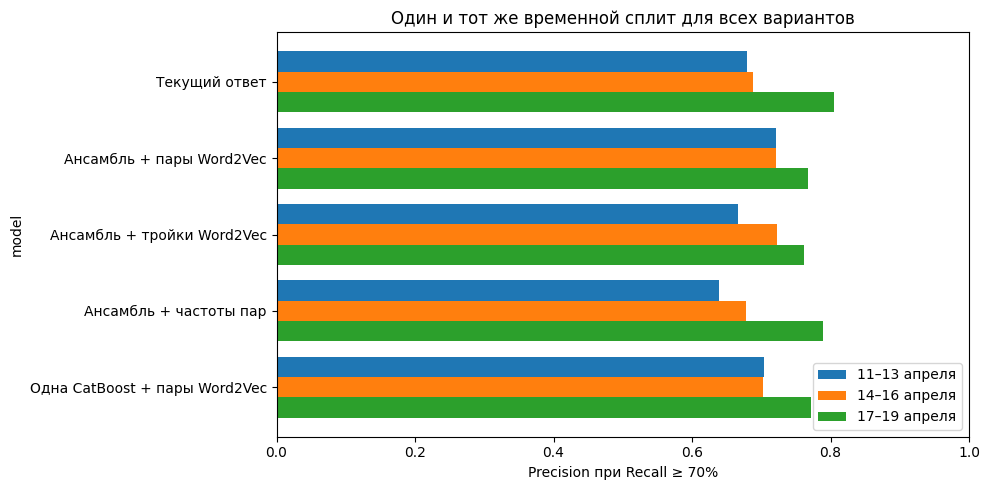

In [4]:
labels = {
    "current_rank": "Текущий ответ",
    "ensemble_word2vec": "Ансамбль + пары Word2Vec",
    "ensemble_trigram": "Ансамбль + тройки Word2Vec",
    "ensemble_pairs": "Ансамбль + частоты пар",
    "word2vec": "Одна CatBoost + пары Word2Vec",
}
shown = summary.set_index("model").loc[list(labels)].rename(index=labels)
ax = shown[["fold_1", "fold_2", "fold_3"]].plot.barh(figsize=(10, 5), width=.8)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_title("Один и тот же временной сплит для всех вариантов")
ax.legend(["11–13 апреля", "14–16 апреля", "17–19 апреля"], loc="lower right")
plt.tight_layout()
plt.show()

## Что получилось

Лучший новый вариант, три CatBoost с Word2Vec по парам, получил **0,737** в среднем по трём отрезкам против **0,725** у нынешнего ответа. На первых двух отрезках стало лучше: **0,722 против 0,680** и **0,721 против 0,688**. На последнем хуже: **0,767 против 0,806**. Общая метрика на всех проверочных куках: **0,731 против 0,712**. Это обнадёживает, но не выглядит устойчивой победой на каждом периоде.

Тройки хуже пар: **0,717** в среднем для ансамбля. Простые частоты всех пар тоже проиграли: **0,702**. Добавление частот к одной модели с Word2Vec не помогло. Похоже, сжатое представление пар здесь полезнее полного набора из 81 частоты, но на другом периоде соотношение может поменяться.

У среднего вектора есть предел: оно определяется частотами пар. Оно не может узнать то, чего вообще нет в списке пар, и не помнит, в каком месте суточного маршрута встретилась цепочка. Разница с прямыми частотами возникает из-за того, как CatBoost работает с компактным набором чисел. Результат тоже уже частично подогнан под знакомые нам три отрезка: мы много раз проверяли на них новые идеи. Поэтому пока **оставляем `output/submission.csv` прежним**, а новый ответ сохраняем отдельно как кандидата.

In [5]:
candidate = pd.read_csv(root / "output" / "sequence_candidate.csv")
test = pd.read_csv(root / "data" / "test.csv")
assert candidate.columns.tolist() == ["cookie_id", "score"]
assert candidate.cookie_id.equals(test.cookie_id)
assert candidate.score.notna().all() and candidate.score.between(0, 1).all()
print(f"В отдельном файле {len(candidate)} кук, пропусков нет")

В отдельном файле 4909 кук, пропусков нет


## Дальше

Если хочется проверить именно порядок длиннее трёх кликов, следующий честный шаг: признаки начала и конца сессии или модель, которая читает цепочку целиком. Этот опыт показывает, что локальный порядок в парах полезен на части периодов, но оснований менять итоговый файл пока мало.